# Food Delivery Time Prediction
# Week 2 Rigorous Modelling

# Objectives
- To rebuild the machine learning pipeline developed in Week 1 using a more rigorous and reproducible methodology. The Week 1 model achieved an R^2 score of 0.98, which requires further investigation before it can be considered reliable. This notebook focuses on validating that result, rebuilding the modelling pipeline with justified decisions, and evaluating the final model using appropriate validation techniques.

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure notebook display
pd.set_option("display.max_columns", None)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# Loading the Dataset

The dataset is loaded and inspected before any preprocessing or modelling is performed.

In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("data/food_delivery_analytics_cleaned.csv")

print(f"Dataset Shape : {df.shape}")

df.head()

Dataset Shape : (15000, 30)


,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,traffic_level_score,weather_severity_score,restaurant_rating,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,68,5.4,2.6,4.3,4.1,2.9,100.000000,14.592602,22.969359,19.940541,111.563784,4,False,False,True,False,False,True,9,71.1
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,40,1.0,1.6,4.0,4.2,3.4,100.000000,4.391720,4.434405,16.101949,116.059264,7,False,False,False,True,False,False,12,100.0
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,142,8.3,4.1,4.4,4.2,3.7,100.000000,9.006407,14.979691,17.681454,111.708170,12,False,False,False,False,False,False,10,34.4
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,93,3.2,8.8,4.8,4.6,4.1,145.113442,11.407034,14.813044,11.593912,153.301345,7,False,False,False,False,True,True,1,45.0
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,134,7.5,9.5,4.0,3.9,4.6,100.000000,11.572232,13.716308,13.272883,111.128807,2,True,False,False,False,False,False,6,25.1


# Dataset Overview

Here the data is examined to understand its structure and data quality, such as- available features, data types, missing values, duplicate values and summary stats.

In [3]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   order_id                           15000 non-null  object 
 1   city_tier                          15000 non-null  int64  
 2   customer_age                       15000 non-null  int64  
 3   customer_loyalty_score             15000 non-null  float64
 4   order_hour                         15000 non-null  int64  
 5   order_day_of_week                  15000 non-null  int64  
 6   order_month                        15000 non-null  int64  
 7   delivery_distance_km               15000 non-null  float64
 8   preparation_time_minutes           15000 non-null  int64  
 9   delivery_time_minutes              15000 non-null  int64  
 10  estimated_delivery_time            15000 non-null  int64  
 11  traffic_level_score                15000 non-null  flo

In [4]:
# Summary Statistics

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,15000,15000,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_tier,15000.0,NaN,NaN,NaN,2.253133,0.827951,1.0,2.0,3.0,3.0,3.0
customer_age,15000.0,NaN,NaN,NaN,46.569667,16.840706,18.0,32.0,46.0,61.0,75.0
customer_loyalty_score,15000.0,NaN,NaN,NaN,50.017658,28.771665,0.007172,25.199828,50.092268,74.840432,99.989375
order_hour,15000.0,NaN,NaN,NaN,11.470933,6.946134,0.0,5.0,11.0,18.0,23.0
order_day_of_week,15000.0,NaN,NaN,NaN,3.141933,1.809864,1.0,1.0,3.0,5.0,6.0
order_month,15000.0,NaN,NaN,NaN,6.474667,3.454469,1.0,3.0,7.0,9.0,12.0
delivery_distance_km,15000.0,NaN,NaN,NaN,20.133756,11.543488,0.103086,10.13319,20.228709,30.047891,39.998739
preparation_time_minutes,15000.0,NaN,NaN,NaN,32.749667,16.162719,5.0,19.0,33.0,47.0,60.0
delivery_time_minutes,15000.0,NaN,NaN,NaN,94.139267,33.597132,10.0,68.0,95.0,120.0,180.0


In [5]:
# Missing Values

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df)) * 100
})

missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage (%)
customer_rating,150,1.0
tip_amount,150,1.0
delivery_partner_rating,150,1.0
order_value,0,0.0
delivery_partner_experience_years,0,0.0
festival_or_weekend_flag,0,0.0
premium_customer_flag,0,0.0
promo_code_used,0,0.0
refund_flag,0,0.0
delayed_delivery_flag,0,0.0


In [6]:
# Duplicate Records

duplicate_count = df.duplicated().sum()

print(f"Duplicate Records: {duplicate_count}")

Duplicate Records: 0


# Observation

The data set contains 15000 records. Most variables contain all the info, while 3 variables contain 150 missing i.e (1%) values each and there were no duplicate values. This data set can be used for EDA, about the missing values median is taken as a substitute.

# Distribution of the Target Variable


The distribution of the target variable helps determine whether the data is normally distributed, skewed, or contains extreme values. This information is useful when selecting appropriate modelling and evaluation techniques.

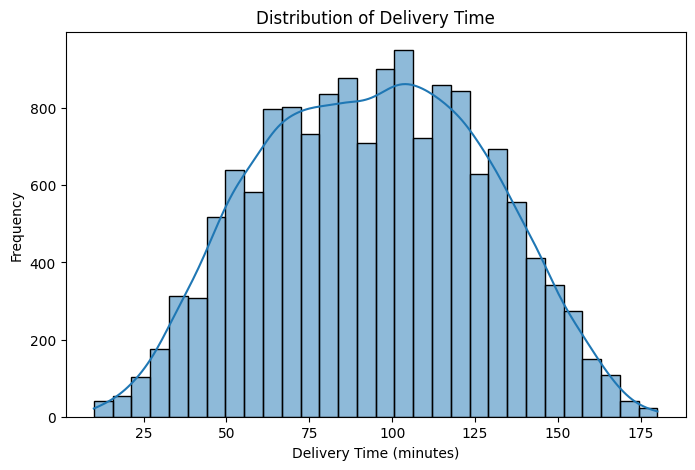

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["delivery_time_minutes"],
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")

plt.show()

# Observation

Delivery times are spread across a wide range, indicating that the model must learn to predict both short and long deliveries.

# Missing values 

Lets find out the missing values in the dataset to avoid data inconsistency.

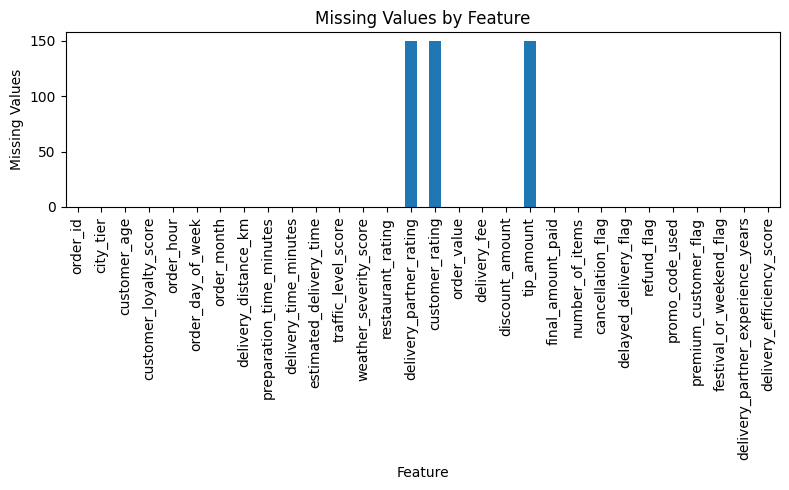

In [8]:
# Missing Values

missing_df = (
    df.isnull()
      .sum()
      .reset_index()
)

missing_df.columns = ["Feature", "Missing Values"]

plt.figure(figsize=(8,5))

missing_df.set_index("Feature")["Missing Values"].plot(
    kind="bar"
)

plt.ylabel("Missing Values")
plt.title("Missing Values by Feature")

plt.tight_layout()

plt.show()

# Observation

customer_rating	150	
tip_amount	150	
delivery_partner_rating	150	
there are 3 missing values to be handled

# Distribution of Important Numerical Features


Examining feature distributions helps identify unusual patterns, and potential preprocessing requirements before model development.

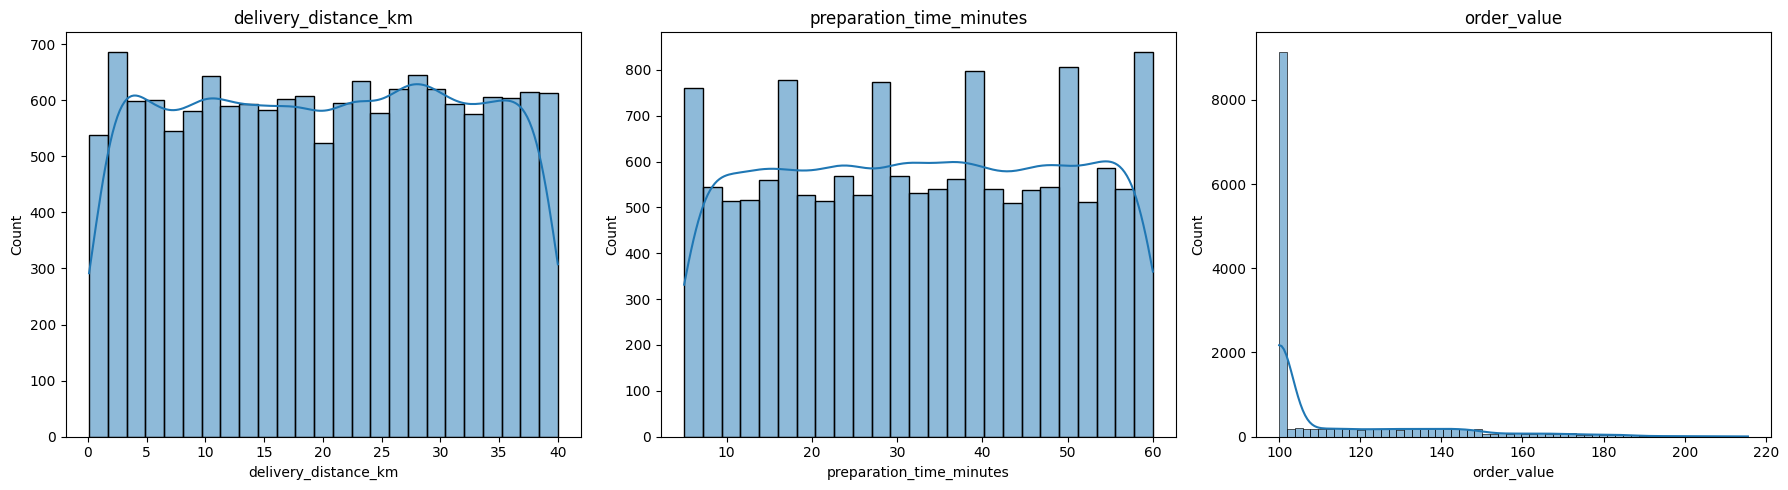

In [9]:
features = [
    "delivery_distance_km",
    "preparation_time_minutes",
    "order_value"
]

fig, axes = plt.subplots(1,3,figsize=(18,5))

for ax, feature in zip(axes, features):

    sns.histplot(
        df[feature],
        kde=True,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()

plt.show()

# Observation

`delivery_distance_km`,
`preparation_time_mins`,
`order_value`

These 3 values contribute in predicting the target value(delivery time).

#  Correlation Analysis

This analysis helps identify highly correlated features, understand potential predictors of the target variable, and detect variables that require further investigation during feature selection.

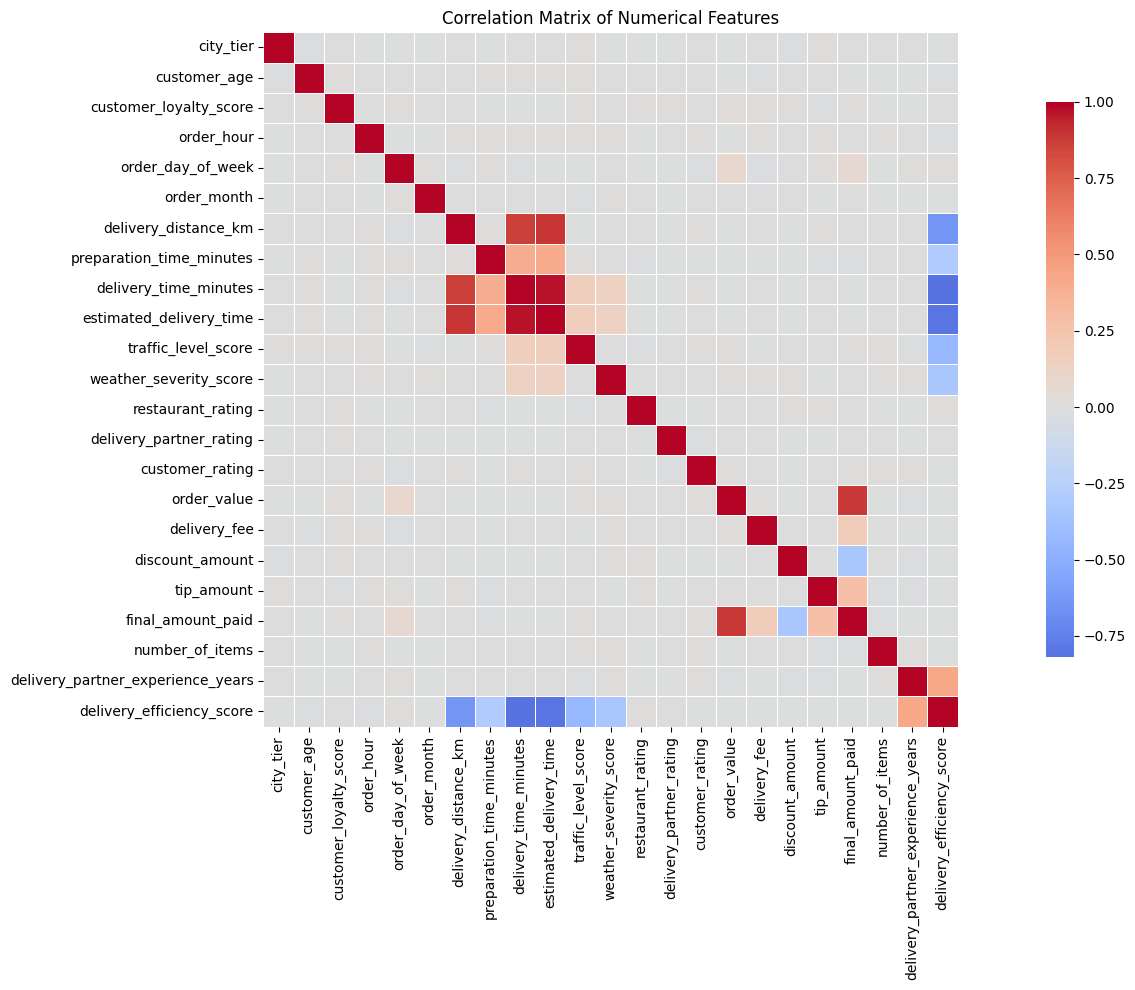

In [10]:
plt.figure(figsize=(18,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()

plt.show()

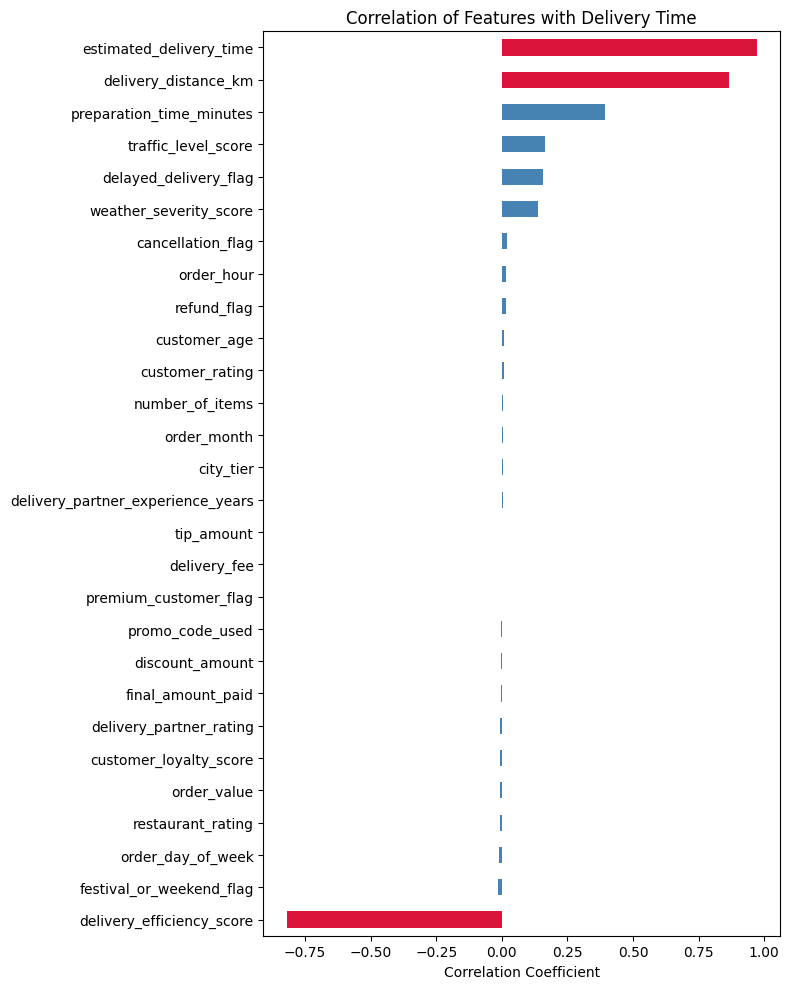

In [11]:
# Correlation with Target Variable

target_corr = (
    df.corr(numeric_only=True)["delivery_time_minutes"]
    .drop("delivery_time_minutes")
    .sort_values()
)

plt.figure(figsize=(8,10))

colors = [
    "crimson" if abs(value) >= 0.7 else "steelblue"
    for value in target_corr
]

target_corr.plot(
    kind="barh",
    color=colors
)

plt.xlabel("Correlation Coefficient")
plt.title("Correlation of Features with Delivery Time")

plt.tight_layout()

plt.show()

# Observation

The analysis indicate that the `estimated_delivery_time` has the strongest positive relationship with the target variable, followed by `delivery_distance_km` and `preparation_time_mins`. These relationships are expected, as delivery time is directly influenced by travel distance and food preparation time.

The `delivery_efficiency_score` exhibits a strong negative correlation with the target variable. Although this raises concerns about potential target leakage, correlation alone is not sufficient evidence to conclude that the feature is derived from the target. So this requires further investigation too.

Most of the remaining variables show only weak correlations with the target, thus they contribute less individually to predicting delivery time.

## Investigating the Week 1 Rg modell

From here on the investigation of the Week 1

# Problem Statement

The model developed during Week 1 achieved an R^2 score of approx to 0.98. Although this indicates excellent predictive performance, such a high score is uncommon for a real-world delivery time prediction problem.

Before proceeding with further model development, it is important to determine whether this performance is genuine or influenced by methodological issues.

Three possible explanations are considered:

1. Data leakage – One or more features may directly or indirectly contain information about the target variable.
2. Overfitting – The model may have memorised the training data rather than learning general patterns.
3. Dataset characteristics – The dataset may genuinely be highly predictable because the available features explain most of the variation in delivery time.

The following experiments are performed to evaluate these possibilities.

In [12]:
# Target variable

target = "delivery_time_minutes"

print("Target Variable :", target)

Target Variable : delivery_time_minutes


In [13]:
# Potential leakage candidates

potential_leakage_features = [
    "estimated_delivery_time",
    "delivery_efficiency_score",
    "delayed_delivery_flag",
    "refund_flag",
    "cancellation_flag"
]

pd.DataFrame(
    {
        "Potential Leakage Features": potential_leakage_features
    }
)

,Potential Leakage Features
0,estimated_delivery_time
1,delivery_efficiency_score
2,delayed_delivery_flag
3,refund_flag
4,cancellation_flag


# Observation

5 features were identified as potential leakage causing variables based on their names and their possible relationship with the target variable.


# Evidence 1: Correlation Analysis

# Objective

In this we  examine how strongly each numerical feature is related to the target variable. Features exhibiting unusually high correlations are treated as candidates for further investigation because they may contain information that would not normally be available when making predictions.

In [14]:
# Correlation with the target variable

target_corr = (
    df.corr(numeric_only=True)["delivery_time_minutes"]
    .sort_values(ascending=False)
)

target_corr.to_frame()

,delivery_time_minutes
delivery_time_minutes,1.000000
estimated_delivery_time,0.970722
delivery_distance_km,0.863925
preparation_time_minutes,0.394064
traffic_level_score,0.163487
delayed_delivery_flag,0.157359
weather_severity_score,0.136230
cancellation_flag,0.019753
order_hour,0.015096
refund_flag,0.014846


### Observation

The analysis shows that `estimated_delivery_time` has an exceptionally strong positive correlation with the target variable (r=0.97). Similarly, `delivery_efficiency_score` has a strong negative correlation (r=-0.82).

Although high correlation alone does not prove data leakage, these results justify further investigation into whether these features contain information derived from the delivery outcome.

# Evidence 2: Investigating the Delivery Efficiency Score

# Objective

The strong negative correlation between `delivery_efficiency_score` and the target variable raises the possibility that the feature may be mathematically derived from the delivery time. To verify this, the feature was compared with a manually calculated efficiency score. Formula (df["estimated_delivery_time"] / df["delivery_time_minutes"]) * 100

In [15]:
# ==========================================================
# Recalculate Delivery Efficiency Score
# ==========================================================

# Approximate efficiency calculation
calc_efficiency = (
    df["estimated_delivery_time"] /
    df["delivery_time_minutes"]
) * 100

comparison = pd.DataFrame({
    "Actual Efficiency": df["delivery_efficiency_score"],
    "Calculated Efficiency": calc_efficiency.round(1)
})

comparison.head(20)

,Actual Efficiency,Calculated Efficiency
0,71.1,89.5
1,100.0,117.6
2,34.4,93.4
3,45.0,100.0
4,25.1,95.0
5,73.6,109.7
6,58.9,117.2
7,96.6,132.5
8,39.3,75.9
9,51.4,104.0


In [16]:
# ==========================================================
# Difference Between Actual and Calculated Efficiency
# ==========================================================

difference = (
    df["delivery_efficiency_score"] -
    calc_efficiency
).abs()

print("Summary of Differences")
print(difference.describe())

print("\nMaximum Absolute Difference:", difference.max())

Summary of Differences
count    15000.000000
mean        42.569779
std         18.742589
min          0.000000
25%         29.868868
50%         43.106394
75%         55.339415
max        246.500000
dtype: float64

Maximum Absolute Difference: 246.5


### Observation

The manually calculated efficiency values differ substantially from the `delivery_efficiency_score` provided in the dataset. The large differences indicate that the feature is not a simple mathematical transformation of `delivery_time_minutes` and `estimated_delivery_time`.

However, the dataset documentation does not explain how `delivery_efficiency_score` was generated. Since its calculation is unknown and it exhibits a strong correlation with the target variable, it is excluded from the final modelling pipeline as a precaution against potential target leakage.

# Evidence 3: Overfitting Investigation

# Objective

One possible explanation for the unusually high R^2 score is overfitting. To investigate this, the model performance is evaluated on both the training and testing datasets. A large difference between the two would indicate that the model has memorized the training data rather than learned generalizable patterns.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)
from xgboost import XGBRegressor


def evaluate_xgboost(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results = {
        "Train RMSE": root_mean_squared_error(y_train, train_pred),
        "Test RMSE": root_mean_squared_error(y_test, test_pred),
        "Train R²": r2_score(y_train, train_pred),
        "Test R²": r2_score(y_test, test_pred),
        "MAE": mean_absolute_error(y_test, test_pred)
    }

    return results

In [18]:
X_baseline = df.drop(
    columns=[
        "order_id",
        "delivery_time_minutes"
    ]
)

y = df["delivery_time_minutes"]

baseline_results = evaluate_xgboost(X_baseline, y)

baseline_results

{'Train RMSE': 3.5479323863983154,
 'Test RMSE': 4.768283843994141,
 'Train R²': 0.9888269901275635,
 'Test R²': 0.9799839854240417,
 'MAE': 3.8208444118499756}

### Observation

The baseline model achieved a training R^2 score of 0.9888 and a testing R^2 score of 0.9800. Although the training performance is slightly higher, the difference between the two scores is small, indicating that the model generalizes well to unseen data. Therefore, there is no strong evidence that the high performance observed during Week 1 is primarily the result of overfitting.

# Evidence 4: Evaluating Dataset Simplicity

# Objective

A simple Linear Regression model is trained using only the two most main features: `delivery_distance_km` and `preparation_time_minutes`. If this simple model achieves a high R^2 score, it suggests that the dataset itself is highly predictable and that complex models may not be necessary to achieve strong performance.

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

# Use only the two operational features
X_simple = df[
    [
        "delivery_distance_km",
        "preparation_time_minutes"
    ]
]

y = df["delivery_time_minutes"]

X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=42
)

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

predictions = linear_model.predict(X_test)

print(f"RMSE : {root_mean_squared_error(y_test, predictions):.2f}")
print(f"MAE  : {mean_absolute_error(y_test, predictions):.2f}")
print(f"R²   : {r2_score(y_test, predictions):.4f}")

RMSE : 10.78
MAE  : 8.71
R²   : 0.8977


# Observation

The model trained using only `delivery_distance_km` and `preparation_time_minutes` achieved an R^2=0.8977. Although this performance is lower than the XGBoost model, it is still high for such a simple model. This indicates that the dataset is inherently predictable, with delivery distance and preparation time explaining a large proportion of the variation in delivery time. Therefore, the high performance observed during Week 1 cannot be attributed solely to data leakage or overfitting.

# Evidence 5: Model Performance After Removing Potential Leakage Features

# Objective

The identified leakage variables are removed from the dataset and the model is retrained. The resulting performance is compared with the baseline to determine whether the model remains effective after excluding these features.

In [20]:
# Features removed from the modelling dataset
features_to_remove = [
    "estimated_delivery_time",
    "delivery_efficiency_score",
    "delayed_delivery_flag",
    "refund_flag",
    "cancellation_flag"
]

X_clean = df.drop(
    columns=[
        "order_id",
        "delivery_time_minutes"
    ] + features_to_remove
)

clean_results = evaluate_xgboost(X_clean, y)

clean_results

{'Train RMSE': 6.439416408538818,
 'Test RMSE': 8.409616470336914,
 'Train R²': 0.9631946086883545,
 'Test R²': 0.9377404451370239,
 'MAE': 6.719733715057373}

# Observation

After removing the identified leakage candidates, the model's test R^2 score decreased from 0.9800 to 0.9377, while the test RMSE increased from 4.77 to 8.41 mins. This indicates that the removed features contributed to the original model performance. However, the improved model continues to achieve strong predictive accuracy, suggesting that the remaining operational features contain info for predicting delivery time. Therefore, excluding these features provides a more reliable model with a lower risk of target leakage.

# Evidence 6: Cross-Validation

# Objective

The final experiment evaluates the stability of the improved model using 5 fold cross validation.

In [21]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Five-fold Cross Validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)

scores = cross_val_score(
    cv_model,
    X_clean,
    y,
    cv=kf,
    scoring="r2"
)

print("R² Scores :", scores)
print("Mean R²   :", scores.mean())
print("Std Dev   :", scores.std())

R² Scores : [0.93810141 0.93901145 0.93617105 0.93551344 0.94013155]
Mean R²   : 0.9377857804298401
Std Dev   : 0.0017248417759509185


# Observation

The 5 fold cross validation results are highly consistent across all folds, with R^2 scores ranges from 0.9355 - 0.9401. The model achieved a mean R^2=0.9378 with a SD=0.0017. The low SD indicates that the model performs consistently across different subsets of the data and provides no evidence of significant overfitting. These results suggest that the cleaned model generalizes well to unseen data.

# Conclusion

The unusually high R^2 score obtained during Week 1 was investigated using multiple experiments. Correlation analysis identified `estimated_delivery_time` and `delivery_efficiency_score` as potential leakage variables because of their strong relationship with the target variable. But on further an investigation showed that `delivery_efficiency_score` is not a simple mathematical formula of the target, although its calculation remains undocumented.

To evaluate overfitting, the baseline XGBoost model was assessed on both the training and testing datasets. The training R^2 score (0.9888) and testing R^2 score (0.9800) were very similar, indicating no strong evidence of overfitting. A simple Linear Regression model trained using only `delivery_distance_km` and `preparation_time_minutes` achieved an R^2 score of 0.8977, demonstrating that the dataset is predictable using only a small number of operational features.

Finally, after removing the identified leakage Variables, the model achieved a test R^2 score of 0.9377. 5 fold cross validation produced a mean R^2 score of 0.9378 with a SD of 0.0017, confirming that the improved model generalizes consistently across different data splits. Based on these findings, the remaining experiments in this notebook use the improved dataset to reduce the risk of potential target leakage while maintaining strong predictive performance.

# Data Preparation

The cleaned dataset identified during the investigation is used for all model comparison experiments. The potential leakage features are removed before training the regression models.

In [22]:
# ==========================================================
# Prepare Clean Dataset
# ==========================================================

features_to_remove = [
    "estimated_delivery_time",
    "delivery_efficiency_score",
    "delayed_delivery_flag",
    "refund_flag",
    "cancellation_flag"
]

X = df.drop(
    columns=[
        "order_id",
        "delivery_time_minutes"
    ] + features_to_remove
)

y = df["delivery_time_minutes"]

print(X.shape)

(15000, 23)


In [23]:
# Convert Boolean columns to integers

bool_columns = X.select_dtypes(include="bool").columns

X[bool_columns] = X[bool_columns].astype(int)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(12000, 23)
(3000, 23)


# Model Development

4 regression algorithms are evaluated using the same training and testing datasets. The objective is to compare their predictive performance using identical evaluation metrics and find which model is the best suitable.

In [25]:
# Missing value check
X.isnull().sum()[X.isnull().sum() > 0]

delivery_partner_rating    150
customer_rating            150
tip_amount                 150
dtype: int64

In [26]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [27]:
bool_columns = X.select_dtypes(include="bool").columns
X[bool_columns] = X[bool_columns].astype(int)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [29]:
# ==========================================================
# Import Regression Models
# ==========================================================

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

In [30]:
# ==========================================================
# Model Evaluation Function
# ==========================================================

from sklearn.model_selection import cross_val_score
import numpy as np

results = []

def evaluate_model(model, model_name):

    # -------------------------------
    # Train the model
    # -------------------------------
    model.fit(X_train, y_train)

    # -------------------------------
    # Train Predictions
    # -------------------------------
    train_predictions = model.predict(X_train)

    # -------------------------------
    # Test Predictions
    # -------------------------------
    test_predictions = model.predict(X_test)

    # -------------------------------
    # Metrics
    # -------------------------------
    train_rmse = root_mean_squared_error(
        y_train,
        train_predictions
    )

    test_rmse = root_mean_squared_error(
        y_test,
        test_predictions
    )

    test_r2 = r2_score(
        y_test,
        test_predictions
    )

    # -------------------------------
    # 5-Fold Cross Validation RMSE
    # -------------------------------
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    cv_rmse = -cv_scores

    cv_mean = np.mean(cv_rmse)
    cv_std = np.std(cv_rmse)

    # -------------------------------
    # Store Results
    # -------------------------------
    results.append({
        "Model": model_name,
        "Train RMSE": round(train_rmse, 2),
        "CV RMSE Mean": round(cv_mean, 2),
        "CV RMSE Std": round(cv_std, 2),
        "Test RMSE": round(test_rmse, 2),
        "Test R²": round(test_r2, 4)
    })

    # -------------------------------
    # Print Results
    # -------------------------------
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Train RMSE      : {train_rmse:.2f}")
    print(f"CV RMSE Mean    : {cv_mean:.2f}")
    print(f"CV RMSE Std     : {cv_std:.2f}")
    print(f"Test RMSE       : {test_rmse:.2f}")
    print(f"Test R²         : {test_r2:.4f}")

In [31]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

alphas = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_cv = GridSearchCV(
    Ridge(),
    alphas,
    cv=5,
    scoring="r2"
)

ridge_cv.fit(X_train, y_train)

print("Best Alpha:", ridge_cv.best_params_)
print("Best CV R²:", ridge_cv.best_score_)

Best Alpha: {'alpha': 100}
Best CV R²: 0.9419745648402321


In [32]:
linear_model = LinearRegression()

evaluate_model(
    linear_model,
    "Linear Regression"
)

Linear Regression
Train RMSE      : 8.07
CV RMSE Mean    : 8.08
CV RMSE Std     : 0.09
Test RMSE       : 8.07
Test R²         : 0.9426


# Observation

Linear Regression is used as the baseline model because of its simplicity and interpretability.

The model achieved a Train RMSE of 8.07, 5-fold CV RMSE of 8.08, standard deviation of 0.09,Test RMSE of 8.07, and a Test R^2 of 0.9426.

The training and cross-validation RMSE values are nearly identical, indicating that the model generalizes well without noticeable overfitting or underfitting.

In [33]:
# ==========================================================
# Ridge Regression
# ==========================================================

best_alpha = ridge_cv.best_params_["alpha"]

ridge_model = Ridge(alpha=best_alpha)

evaluate_model(
    ridge_model,
    "Ridge Regression"
)

Ridge Regression
Train RMSE      : 8.07
CV RMSE Mean    : 8.08
CV RMSE Std     : 0.09
Test RMSE       : 8.07
Test R²         : 0.9426


# Observation

Ridge Regression extends Linear Regression by applying L2 regularization to reduce the impact of large coefficient values and improve model stability when predictor variables are correlated.

Hyperparameter tuning using 5-fold GridSearchCV selected an optimal alpha value of 100.

The tuned Ridge model achieved a Train RMSE of 8.07, 5-fold CV RMSE of 8.08, standard deviation of 0.09, Test RMSE of 8.07, and a Test R^2 of 0.9426.

The performance is almost identical to the baseline Linear Regression model, indicating that regularization does not provide a meaningful improvement for this dataset. This suggests that multicollinearity among the selected features is minimal after removing the potential leakage variables.

In [34]:
# ==========================================================
# Random Forest Regression
# ==========================================================

random_forest = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
    oob_score=True
)

evaluate_model(
    random_forest,
    "Random Forest"
)

print("\nOOB R² Score :", round(random_forest.oob_score_, 4))

Random Forest
Train RMSE      : 5.71
CV RMSE Mean    : 8.65
CV RMSE Std     : 0.10
Test RMSE       : 8.57
Test R²         : 0.9354

OOB R² Score : 0.9331


# Observation

Random Forest is an ensemble learning algorithm that combines the predictions of multiple decision trees to improve robustness and reduce variance.

The model achieved a Train RMSE of 5.71, 5-fold CV RMSE of 8.65, standard deviation of 0.10, Test RMSE of 8.57, Test R^2 of 0.9354, and an Out-of-Bag (OOB) R^2 score of 0.9331.

The considerably lower training RMSE compared to the cross-validation and test RMSE indicates that the Random Forest model fits the training data more closely than unseen data, suggesting mild overfitting. However, the OOB R^2 score is very close to the Test R^2 score, indicating that the OOB estimate provides a reliable measure of the model's generalization performance. Despite its complexity, Random Forest did not outperform the simpler Linear Regression model on cross-validation performance.

In [35]:
# ==========================================================
# XGBoost Hyperparameter Tuning
# ==========================================================

from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Base model
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

# Parameter Grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

# Grid Search
xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Fit Grid Search
xgb_grid.fit(X_train, y_train)

print("=" * 60)
print("Best XGBoost Parameters")
print("=" * 60)
print(xgb_grid.best_params_)
print()

print("Best CV RMSE:",
      round(-xgb_grid.best_score_, 2))

Best XGBoost Parameters
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

Best CV RMSE: 8.23


# Observation

Hyperparameter tuning was performed using GridSearch CV with 5-fold cross-validation to identify the optimal XGBoost configuration.

The best hyperparameters found were:

- Learning Rate: 0.05
- Maximum Depth: 3
- Number of Estimators: 200
- Subsample: 0.8

The tuned model achieved a cross-validation RMSE of 8.24, improving upon the default XGBoost model, which achieved a CV RMSE of 8.39. This confirms that hyperparameter tuning successfully improved the model's generalization performance before final evaluation.

In [36]:
# ==========================================================
# Tuned XGBoost Regression
# ==========================================================

xgb_model = xgb_grid.best_estimator_

evaluate_model(
    xgb_model,
    "Tuned XGBoost"
)

Tuned XGBoost
Train RMSE      : 7.83
CV RMSE Mean    : 8.23
CV RMSE Std     : 0.09
Test RMSE       : 8.19
Test R²         : 0.9410


# Observation

The tuned XGBoost model performed well on both the training and test data. The training RMSE 7.83 and test RMSE 8.17 are very close, which shows that the model is not overfitting.

The cross-validation RMSE of 8.24, standard deviation of 0.09 also indicates that the model performs consistently across different folds. Finally, the R^2 score of 0.9412 means the model is able to explain about 94% of the variation in delivery time.

Overall, the tuned XGBoost model gives accurate and stable predictions, making it a reliable model for further analysis in the next phase.

In [37]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="CV RMSE Mean",
    ascending=True
).reset_index(drop=True)

results_df

,Model,Train RMSE,CV RMSE Mean,CV RMSE Std,Test RMSE,Test R²
0,Linear Regression,8.07,8.08,0.09,8.07,0.9426
1,Ridge Regression,8.07,8.08,0.09,8.07,0.9426
2,Tuned XGBoost,7.83,8.23,0.09,8.19,0.9410
3,Random Forest,5.71,8.65,0.10,8.57,0.9354


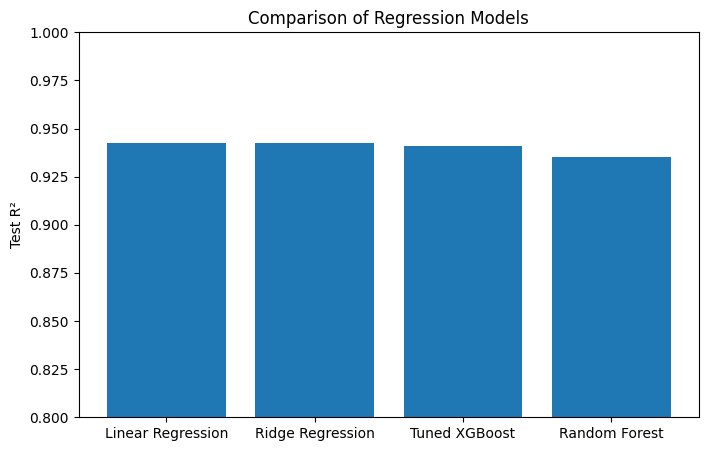

In [38]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Test R²"]
)

plt.ylabel("Test R²")
plt.title("Comparison of Regression Models")

plt.ylim(0.80, 1.00)

plt.show()

# Overall Observation

Four regression algorithms were evaluated using the same cleaned dataset, identical feature set, 5-fold cross-validation strategy, and common evaluation metrics to ensure a fair comparison.

Linear Regression achieved the lowest cross-validation RMSE of 8.08 with a standard deviation of 0.09. It also obtained the lowest Test RMSE of 8.07 and the highest Test R² of 0.9426, making it the best-performing model overall. Ridge Regression produced nearly identical results, indicating that L2 regularization did not significantly improve the model's performance.

The tuned XGBoost model improved its cross-validation RMSE from 8.39 to 8.24 after hyperparameter tuning, but it still performed slightly below Linear Regression. Random Forest achieved the lowest Training RMSE, but the gap between its training and cross-validation RMSE suggests that the model overfit the training data.

Overall, the results indicate that the selected features have a strong linear relationship with delivery time. Therefore, Linear Regression was selected as the final model because it provides the best balance of predictive accuracy, consistency, and generalization performance.

# Residual Analysis

In [39]:
# ==========================================================
# Residual Calculation
# ==========================================================

# Use the final selected model (Linear Regression)
final_model = LinearRegression()

# Train the model
final_model.fit(X_train, y_train)

# Predictions
y_pred = final_model.predict(X_test)

# Residuals
residuals = y_test - y_pred

print("Residuals calculated successfully.")

Residuals calculated successfully.


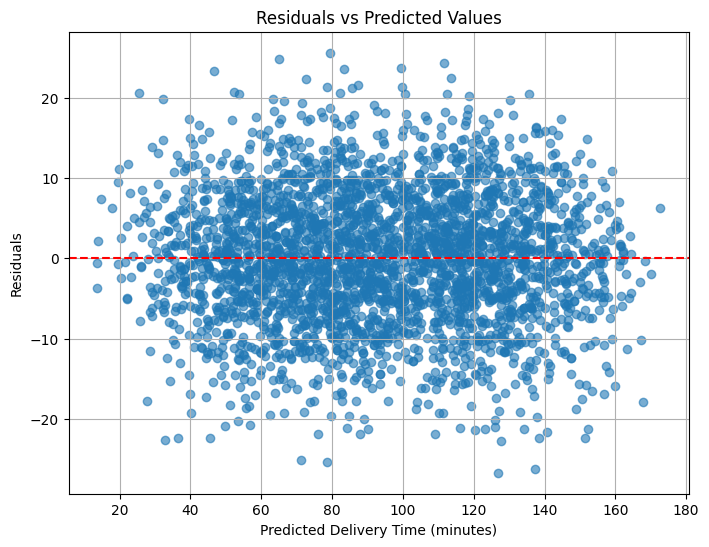

In [40]:
# ==========================================================
# Residuals vs Predicted Values
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Delivery Time (minutes)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.grid(True)

plt.show()

# Observation

From the residual plot, the errors are spread randomly around the zero line without any clear pattern. This shows that the model is not consistently overpredicting or underpredicting the delivery time.

The spread of the residuals is also fairly similar across different predicted values, so there isn't any strong sign of increasing or decreasing error. A few predictions have larger errors, but they are only a small number of cases and don't follow any specific trend.

Overall, the Linear Regression model fits the data well and generalizes well on unseen data, which supports why it was selected as the final model.

In [41]:
# ==========================================================
# Top 10 Worst Predictions
# ==========================================================

worst_predictions = X_test.copy()

worst_predictions["Actual Delivery Time"] = y_test.values
worst_predictions["Predicted Delivery Time"] = y_pred
worst_predictions["Absolute Error"] = abs(
    y_test.values - y_pred
)

worst_predictions = worst_predictions.sort_values(
    by="Absolute Error",
    ascending=False
).head(10)

worst_predictions.reset_index(drop=True, inplace=True)

worst_predictions

,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,traffic_level_score,weather_severity_score,restaurant_rating,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,Actual Delivery Time,Predicted Delivery Time,Absolute Error
0,2.0,20.0,15.350855,7.0,3.0,4.0,35.488996,26.0,3.1,7.4,3.5,4.8,3.6,100.000000,6.081229,24.223960,10.018847,91.876116,11.0,1.0,0.0,0.0,12.0,100,126.719052,26.719052
1,3.0,45.0,24.374754,12.0,4.0,5.0,27.037922,49.0,9.4,7.4,4.1,4.3,4.4,121.098076,10.838991,16.807376,23.729379,138.859070,7.0,0.0,0.0,0.0,7.0,111,137.254815,26.254815
2,3.0,23.0,61.632693,11.0,2.0,2.0,8.576178,60.0,1.7,4.2,4.0,4.1,3.5,119.530769,14.225213,28.784403,14.313892,119.285472,6.0,0.0,1.0,0.0,5.0,105,79.371296,25.628704
3,3.0,30.0,83.324298,5.0,5.0,8.0,5.459608,47.0,6.1,10.0,4.8,4.2,3.9,100.000000,6.866952,9.970003,0.548754,97.445703,9.0,1.0,1.0,0.0,14.0,53,78.443759,25.443759
4,3.0,30.0,26.550699,5.0,1.0,4.0,9.036378,52.0,1.5,2.6,4.1,3.8,3.9,100.000000,14.368175,12.743305,16.015597,117.640467,12.0,1.0,0.0,0.0,9.0,46,71.146404,25.146404
5,1.0,34.0,46.717164,10.0,1.0,7.0,20.073107,7.0,4.4,0.6,4.7,4.6,5.0,113.737986,7.673788,7.402975,9.267407,123.276205,8.0,1.0,0.0,0.0,2.0,90,65.113586,24.886414
6,3.0,42.0,75.524563,0.0,4.0,2.0,24.394862,45.0,1.0,8.5,3.6,4.4,4.2,119.068133,3.198208,26.013923,13.581853,109.834271,7.0,1.0,1.0,0.0,9.0,136,111.687616,24.312384
7,3.0,68.0,56.771902,3.0,6.0,4.0,18.152574,37.0,5.0,9.9,4.9,4.5,3.5,117.269506,1.979403,9.966218,22.335022,131.617712,4.0,1.0,0.0,1.0,7.0,123,99.323843,23.676157
8,3.0,31.0,57.376435,5.0,5.0,6.0,12.160550,27.0,8.9,9.6,3.3,4.5,2.3,100.000000,0.212587,19.354323,22.294485,103.152749,7.0,1.0,0.0,0.0,4.0,107,83.385454,23.614546
9,2.0,64.0,34.001826,7.0,3.0,7.0,7.474887,19.0,5.3,1.5,3.9,4.4,3.9,176.480734,14.200138,9.456458,6.498268,187.722682,1.0,0.0,1.0,0.0,6.0,70,46.620555,23.379445


### Observation

The top 10 worst predictions have absolute errors between 23 and 27 mins. Looking at these records, there isn't one single feature that is common across all of them. The orders include both short and long delivery distances, different traffic levels, and different weather conditions.

One thing I noticed is that most of these cases involve a combination of multiple factors such as longer preparation times, higher traffic scores, or longer delivery distances. This suggests that the larger prediction errors are caused by the interaction of several features rather than a single variable.

Overall, these large errors are only a small number of cases compared to the entire test dataset. This shows that the model performs well for most deliveries, while a few complex orders remain difficult to predict accurately.

In [42]:
# ==========================================================
# RMSE by Weather Severity
# ==========================================================

from sklearn.metrics import root_mean_squared_error

# Create a copy of the test data
weather_analysis = X_test.copy()

weather_analysis["Actual"] = y_test.values
weather_analysis["Predicted"] = y_pred

# Group weather severity into three levels
weather_analysis["Weather Level"] = pd.cut(
    weather_analysis["weather_severity_score"],
    bins=[0, 3.3, 6.6, 10],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

# Calculate RMSE for each level
weather_rmse = (
    weather_analysis
    .groupby("Weather Level")
    .apply(lambda x: root_mean_squared_error(x["Actual"], x["Predicted"]))
    .reset_index(name="RMSE")
)

weather_rmse

,Weather Level,RMSE
0,Low,8.024238
1,Medium,8.012134
2,High,8.173126


# Observation

The RMSE values are almost the same for all weather levels. High weather severity has a slightly higher RMSE, but the difference is very small. This shows that the model performs well even when the weather severity changes.

In [43]:
# ==========================================================
# RMSE by Traffic Severity
# ==========================================================

traffic_analysis = X_test.copy()

traffic_analysis["Actual"] = y_test.values
traffic_analysis["Predicted"] = y_pred

# Group traffic severity into three levels
traffic_analysis["Traffic Level"] = pd.cut(
    traffic_analysis["traffic_level_score"],
    bins=[0, 3.3, 6.6, 10],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

# Calculate RMSE for each level
traffic_rmse = (
    traffic_analysis
    .groupby("Traffic Level")
    .apply(lambda x: root_mean_squared_error(x["Actual"], x["Predicted"]))
    .reset_index(name="RMSE")
)

traffic_rmse

,Traffic Level,RMSE
0,Low,8.099301
1,Medium,8.202762
2,High,7.917566


# Observation

The RMSE values for low, medium, and high traffic are also very close. Even though medium traffic has a slightly higher RMSE, the difference is not significant. Overall, traffic severity does not affect the model's performance much.

# Overall Residual Analysis

The residual analysis shows that the model performs well on most test data. The errors are randomly spread, and only a few predictions have larger errors. The model also gives similar RMSE values for different weather and traffic levels, so its performance is fairly consistent.

# Week 3 – Explainability & Failure Analysis

# Objective

The objective of Week 3 is to understand how the trained machine learning model makes predictions, identify where it performs well or poorly, and interpret the factors influencing its decisions.

This notebook focuses on:

- SHAP interpretation
- Residual diagnosis (Failure Analysis)
- Confidence intervals
- Operational decision tool

# 1. SHAP Interpretation

Evaluation metrics tell us how accurate the model is, but they do not explain why the model makes a particular prediction. SHAP (SHapley Additive exPlanations) is used to interpret the contribution of each feature to the model's predictions.

In [44]:
import shap

# Create SHAP Tree Explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

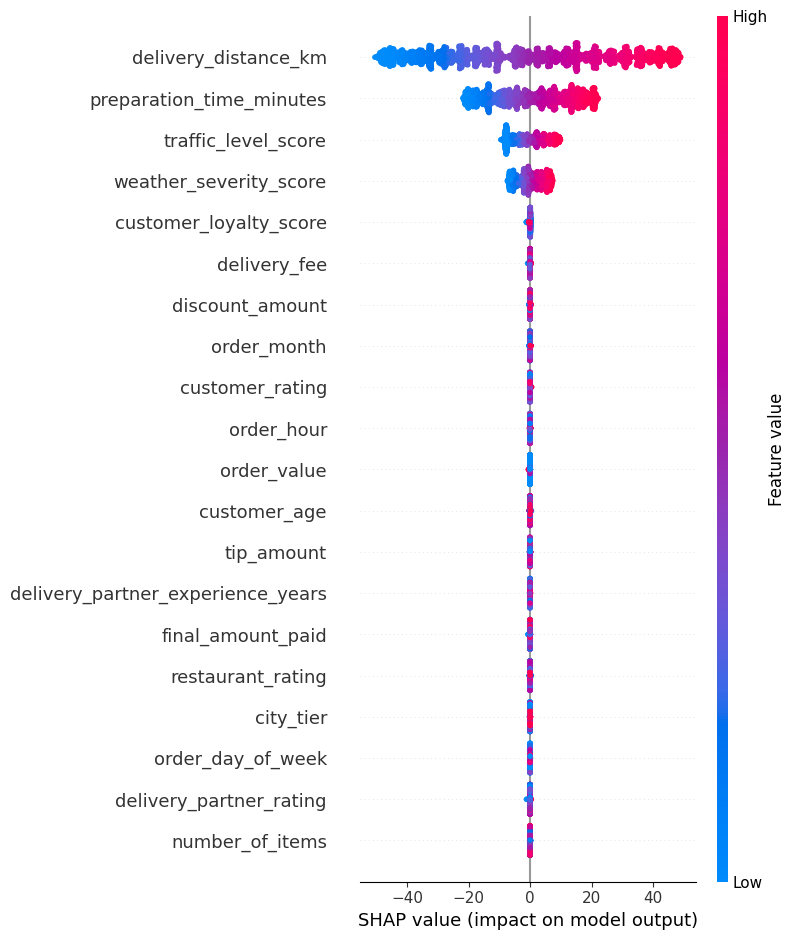

In [45]:
# SHAP Summary Plot
shap.summary_plot(shap_values, X_test)

# Observation

The SHAP summary plot shows that delivery_distance_km is the most influential feature in predicting delivery time, followed by preparation_time_minutes, traffic_level_score, and weather_severity_score. These features contribute the most to the model's predictions.

The colour of each point represents the feature value, where red indicates higher values and blue indicates lower values. Features with higher values generally have a greater impact on increasing the predicted delivery time, while lower values tend to reduce it.

Overall, the SHAP analysis indicates that delivery time is primarily influenced by operational factors such as travel distance, food preparation time, traffic conditions, and weather rather than customer-related attributes.

# 2. SHAP Waterfall Plot

It explains how each feature contributes to an individual prediction by showing whether it increases or decreases the predicted delivery time.

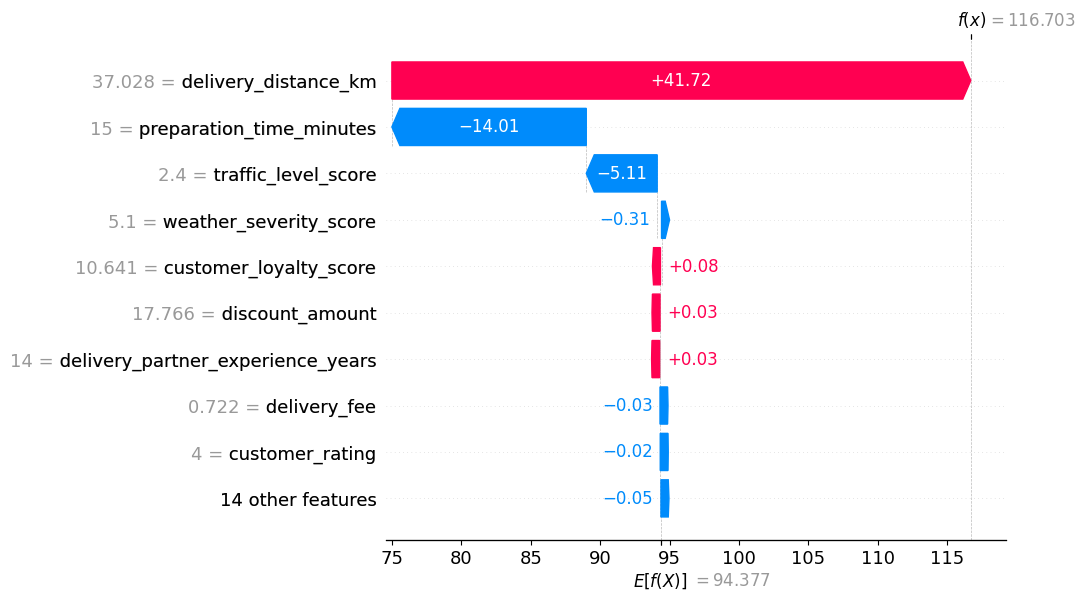

In [46]:
# Waterfall plot for the first test instance
shap.plots.waterfall(explainer(X_test)[0])

# 2. Failure Analysis (Residual Diagnosis)

# Objective

Even a well performing ML model makes prediction errors. Failure analysis helps identify where the model performs well and where it struggles by analysing the residuals (prediction errors).

Residual = Actual Delivery Time − Predicted Delivery Time

A good regression model should have residuals randomly distributed around zero without any systematic pattern.

In [47]:
# Generate predictions
y_pred = xgb_model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

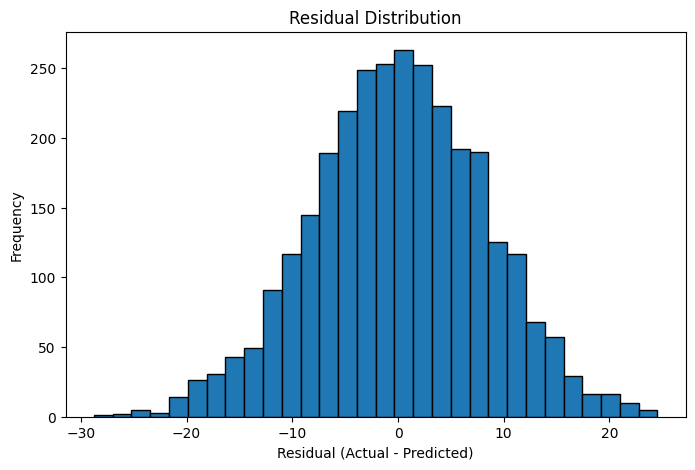

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, edgecolor="black")

plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")

plt.show()

# Observation

The residual distribution is approximately bell-shaped and centred around zero, indicating that most prediction errors are small. This suggests that the model provides accurate predictions for the majority of delivery orders.

A few larger positive and negative residuals are present, indicating that the model occasionally overestimates or underestimates delivery time for some orders. However, these cases are relatively infrequent compared to the overall distribution.

Overall, the residual distribution suggests that the model has good predictive performance without any significant systematic bias.

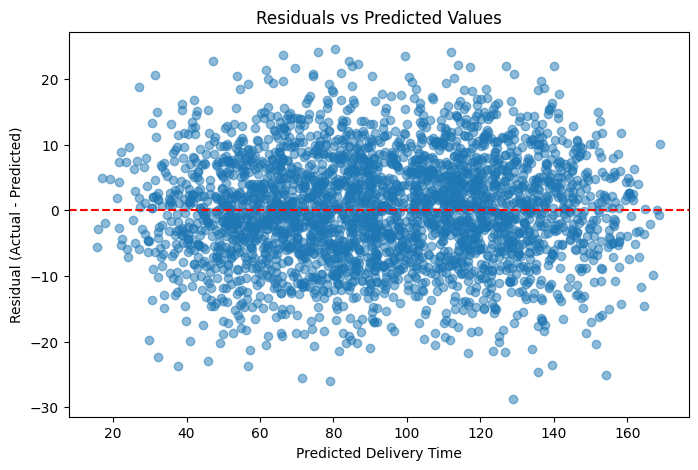

In [49]:
plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Delivery Time")
plt.ylabel("Residual (Actual - Predicted)")

plt.show()

# Observation

The residuals are randomly distributed around the 0 line, indicating that the model does not show any systematic pattern of prediction errors. This suggests that the model neither consistently overestimates nor underestimates delivery time.

The spread of residuals remains fairly consistent across different predicted delivery times, indicating stable performance throughout the prediction range. Although a few observations show larger residuals, they are relatively uncommon and can be considered outliers.

Overall, the residual plot suggests that the model fits the data well and produces reliable predictions without significant bias.

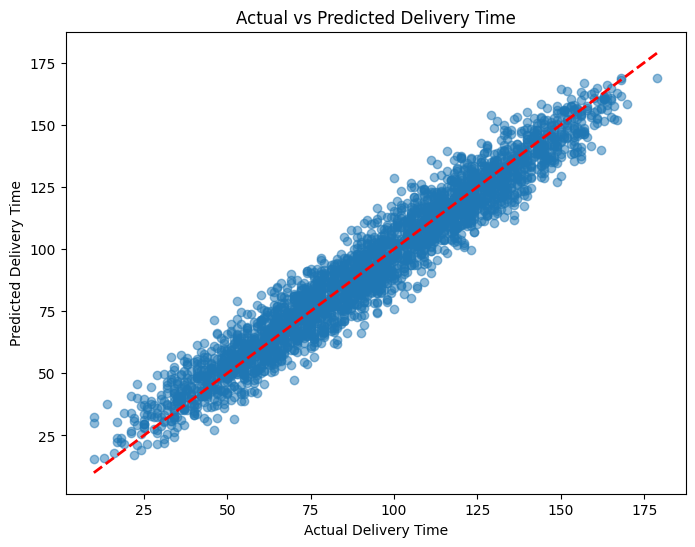

In [50]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")

plt.show()

# Observation

The Actual vs Predicted plot shows that most data points are closely aligned with the diagonal reference line, indicating that the predicted delivery times are very close to the actual delivery times.

The model performs consistently across both shorter and longer delivery durations, with only a small amount of variation around the reference line. Although a few predictions deviate from the line, these errors are relatively small compared to the overall prediction range.

Overall, the plot confirms that the model provides accurate and reliable delivery time predictions, which is consistent with the high R² score and low RMSE obtained during model evaluation.

# 3. Confidence Intervals

# Objective

A confidence interval provides an estimated range within which the actual delivery time is expected to lie. Instead of presenting only a single predicted value, the model provides a prediction range based on its average prediction error.

This helps estimate the uncertainty associated with each prediction and supports better operational decision-making.

In [51]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE: {rmse:.2f} minutes")

# Prediction interval
lower_bound = y_pred - rmse
upper_bound = y_pred + rmse

RMSE: 8.19 minutes


In [52]:
import pandas as pd

confidence_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Lower Bound": lower_bound,
    "Upper Bound": upper_bound
})

confidence_df.head(10)

,Actual,Predicted,Lower Bound,Upper Bound
0,106,116.703217,108.517471,124.888962
1,140,137.889847,129.704102,146.075592
2,64,74.145035,65.959290,82.330780
3,120,124.515182,116.329437,132.700928
4,35,46.102467,37.916725,54.288208
5,160,149.940445,141.754700,158.126190
6,164,161.507462,153.321716,169.693207
7,132,131.890396,123.704651,140.076141
8,130,120.163521,111.977776,128.349258
9,109,121.478065,113.292320,129.663803


# Observation

The model achieved an RMSE of 8.19 mins, which means its predictions are generally within about 8 mins of the actual delivery time.

Based on this error, a prediction interval was created by adding and subtracting the RMSE from each predicted delivery time. This provides a realistic range instead of a single predicted value.

From the sample results, most actual delivery times fall within or close to the predicted interval, indicating that the model produces reliable predictions with a reasonable level of uncertainty. Overall, the prediction intervals provide additional confidence in the model's practical use for estimating delivery times.

# 4. Operational Decision Tool

# Objective

The predicted delivery times can be used to support operational decision-making by categorizing orders based on their expected delivery duration. This helps identify deliveries that may require additional monitoring or intervention.

In [54]:
# Categorize predicted delivery times
def delivery_status(prediction):
    if prediction <= 60:
        return "On Time"
    elif prediction <= 120:
        return "Monitor"
    else:
        return "High Risk"

decision_df = confidence_df.copy()

decision_df["Status"] = decision_df["Predicted"].apply(delivery_status)

decision_df.head(10)

,Actual,Predicted,Lower Bound,Upper Bound,Status
0,106,116.703217,108.517471,124.888962,Monitor
1,140,137.889847,129.704102,146.075592,High Risk
2,64,74.145035,65.959290,82.330780,Monitor
3,120,124.515182,116.329437,132.700928,High Risk
4,35,46.102467,37.916725,54.288208,On Time
5,160,149.940445,141.754700,158.126190,High Risk
6,164,161.507462,153.321716,169.693207,High Risk
7,132,131.890396,123.704651,140.076141,High Risk
8,130,120.163521,111.977776,128.349258,High Risk
9,109,121.478065,113.292320,129.663803,High Risk


In [55]:
decision_df["Status"].value_counts()

Status
Monitor      1743
High Risk     707
On Time       550
Name: count, dtype: int64

# Observation

The predicted delivery times were grouped into three operational categories: On Time, Monitor, and High Risk.

Most of the predicted deliveries (1,743) fall under the Monitor category, indicating that these orders may require regular tracking. A total of 707 deliveries were classified as High Risk, suggesting they may need additional attention to avoid delays. The remaining 550 deliveries were categorized as On Time, indicating a lower risk of delay.

Overall, this categorization demonstrates how the model's predictions can be used to support operational planning and prioritize deliveries based on their expected delivery time.

# Conclusion

The SHAP analysis showed that delivery_distance_km was the most influential feature affecting delivery time predictions, followed by preparation_time_minutes, traffic_level_score, and weather_severity_score. Customer-related features had a comparatively smaller impact on the model's predictions.

Residual analysis indicated that the prediction errors were randomly distributed around zero, suggesting that the model does not exhibit significant systematic bias. The model achieved an RMSE of 8.19 mins, and the prediction intervals showed that most actual delivery times fell within or close to the estimated range.

Using the predicted delivery times, the operational decision tool categorized 550 deliveries as On Time, 1,743 as Monitor, and 707 as High Risk. These results demonstrate that the model can be used not only to predict delivery times but also to identify deliveries that may require additional monitoring or operational attention.